In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load processed data
close_prices = pd.read_csv('../data/processed/close_prices.csv',
                            index_col='Date', parse_dates=True)

tsla = close_prices['TSLA'].dropna()

print(f"TSLA data loaded: {len(tsla)} trading days")
print(f"Date range: {tsla.index[0].date()} to {tsla.index[-1].date()}")
print(f"Latest price: ${tsla.iloc[-1]:.2f}")

TSLA data loaded: 2888 trading days
Date range: 2015-01-02 to 2026-06-29
Latest price: $411.84


In [2]:

print("Preparing data for LSTM...")

# Scale full dataset
scaler = MinMaxScaler(feature_range=(0, 1))
tsla_scaled = scaler.fit_transform(tsla.values.reshape(-1, 1))

# Create sequences from full data
window_size = 60

def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(tsla_scaled, window_size)
X_all = X_all.reshape(X_all.shape[0], X_all.shape[1], 1)

print(f"Training on full dataset: {X_all.shape[0]} sequences")

# Build LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True)

print("Training LSTM on full dataset...")
history = model.fit(
    X_all, y_all,
    batch_size=32,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete!")

Preparing data for LSTM...
Training on full dataset: 2828 sequences
Training LSTM on full dataset...
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - loss: 0.0093 - val_loss: 0.0020
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0021 - val_loss: 0.0035
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0018 - val_loss: 0.0096
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - loss: 0.0015 - val_loss: 0.0025
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0015 - val_loss: 0.0033
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0013 - val_loss: 0.0027
Training complete!


In [ ]:

print("Generating 6-month future forecast...")

forecast_days = 126  # ~6 months of trading days

# Start with last 60 days of real data as seed
last_60_days = tsla_scaled[-window_size:]
current_input = last_60_days.copy()

future_predictions = []

for day in range(forecast_days):
    # Reshape for LSTM input
    X_pred = current_input[-window_size:].reshape(1, window_size, 1)
    
    # Predict next day
    next_pred = model.predict(X_pred, verbose=0)[0, 0]
    future_predictions.append(next_pred)
    
    # Append prediction to input for next iteration
    current_input = np.append(current_input, [[next_pred]], axis=0)

# Inverse transform predictions back to real prices
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_prices = scaler.inverse_transform(future_predictions)

# Create future date index (business days only)
last_date = tsla.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=forecast_days + 1)[1:]

# Create forecast series
forecast_series = pd.Series(future_prices.flatten(), index=future_dates)

print(f"Forecast period: {future_dates[0].date()} to {future_dates[-1].date()}")
print(f"Current price:   ${tsla.iloc[-1]:.2f}")
print(f"Forecast end:    ${forecast_series.iloc[-1]:.2f}")
print(f"Expected change: {((forecast_series.iloc[-1] - tsla.iloc[-1]) / tsla.iloc[-1]) * 100:.2f}%")

Generating 6-month future forecast...
Forecast period: 2026-06-30 to 2026-12-22
Current price:   $411.84
Forecast end:    $413.79
Expected change: 0.47%


In [5]:

print("Generating confidence intervals...")

n_simulations = 50  # reduced for speed
all_simulations = []

for sim in range(n_simulations):
    current_input = tsla_scaled[-window_size:].copy()
    sim_predictions = []
    noise_level = 0.012

    for day in range(forecast_days):
        X_pred = current_input[-window_size:].reshape(1, window_size, 1)
        next_pred = model.predict(X_pred, verbose=0)[0, 0]
        noise = np.random.normal(0, noise_level * (1 + day / forecast_days))
        next_pred_noisy = np.clip(next_pred + noise, 0, 1)
        sim_predictions.append(next_pred_noisy)
        current_input = np.append(current_input, [[next_pred_noisy]], axis=0)

    sim_prices = scaler.inverse_transform(
        np.array(sim_predictions).reshape(-1, 1)
    ).flatten()
    all_simulations.append(sim_prices)
    
    if (sim + 1) % 10 == 0:
        print(f"  Simulation {sim+1}/{n_simulations} done")

simulations_df = pd.DataFrame(all_simulations, columns=future_dates)

ci_95_upper = simulations_df.quantile(0.975)
ci_95_lower = simulations_df.quantile(0.025)
ci_68_upper = simulations_df.quantile(0.84)
ci_68_lower = simulations_df.quantile(0.16)

print(f"\n95% CI at end of forecast:")
print(f"  Upper: ${ci_95_upper.iloc[-1]:.2f}")
print(f"  Lower: ${ci_95_lower.iloc[-1]:.2f}")
print(f"  Width: ${ci_95_upper.iloc[-1] - ci_95_lower.iloc[-1]:.2f}")
print("Done!")

Generating confidence intervals...
  Simulation 10/50 done
  Simulation 20/50 done
  Simulation 30/50 done
  Simulation 40/50 done
  Simulation 50/50 done

95% CI at end of forecast:
  Upper: $447.02
  Lower: $388.18
  Width: $58.84
Done!


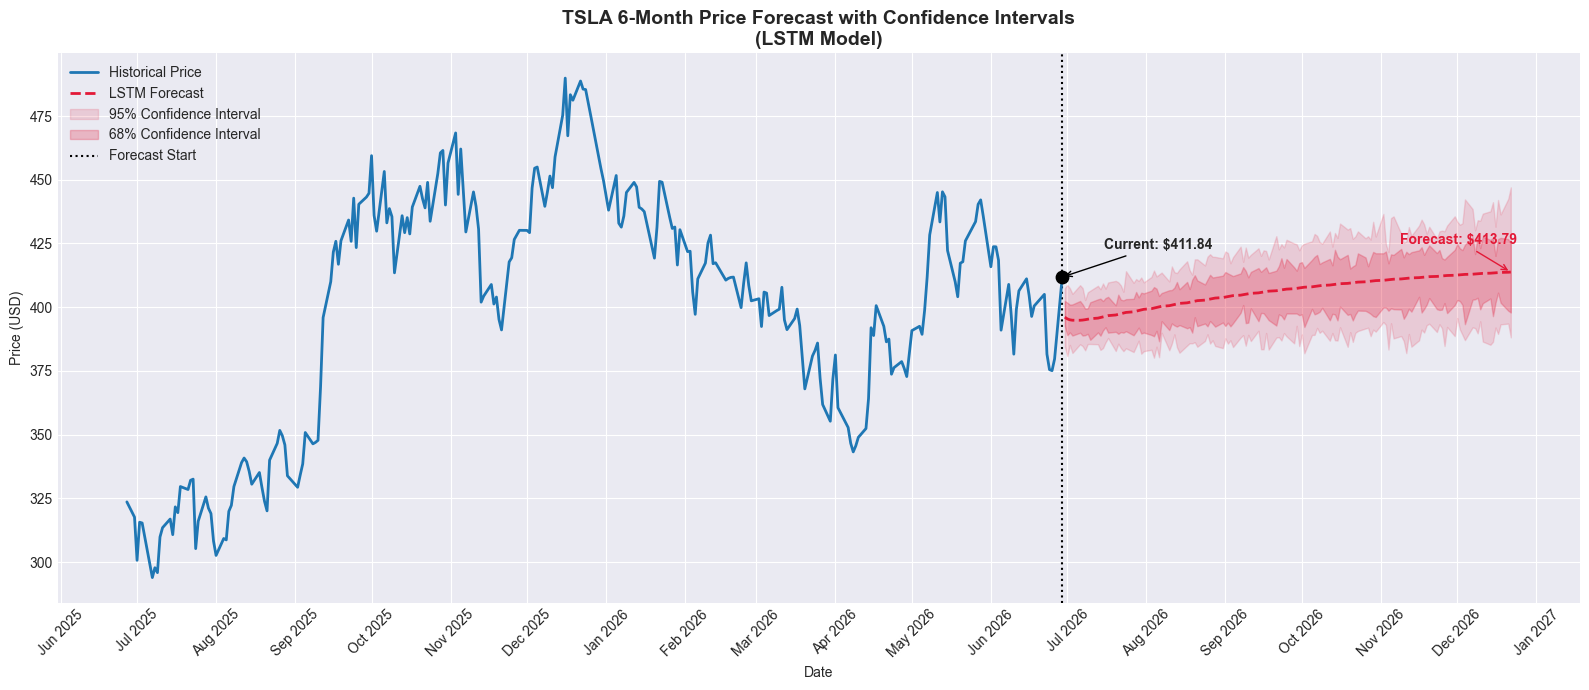

Forecast chart saved!


In [6]:

fig, ax = plt.subplots(figsize=(16, 7))

# Plot last 12 months of historical data
history_window = tsla[-252:]

ax.plot(history_window.index, history_window.values,
        color='#1f77b4', linewidth=2, label='Historical Price', zorder=5)

# Plot forecast
ax.plot(future_dates, forecast_series.values,
        color='#E31937', linewidth=2, linestyle='--',
        label='LSTM Forecast', zorder=5)

# Plot confidence intervals
ax.fill_between(future_dates, ci_95_lower, ci_95_upper,
                alpha=0.15, color='#E31937', label='95% Confidence Interval')
ax.fill_between(future_dates, ci_68_lower, ci_68_upper,
                alpha=0.25, color='#E31937', label='68% Confidence Interval')

# Mark current price
ax.axvline(x=tsla.index[-1], color='black',
           linestyle=':', linewidth=1.5, label='Forecast Start')
ax.scatter([tsla.index[-1]], [tsla.iloc[-1]],
           color='black', s=80, zorder=10)

# Annotations
ax.annotate(f'Current: ${tsla.iloc[-1]:.2f}',
            xy=(tsla.index[-1], tsla.iloc[-1]),
            xytext=(30, 20), textcoords='offset points',
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))

ax.annotate(f'Forecast: ${forecast_series.iloc[-1]:.2f}',
            xy=(future_dates[-1], forecast_series.iloc[-1]),
            xytext=(-80, 20), textcoords='offset points',
            fontsize=10, fontweight='bold', color='#E31937',
            arrowprops=dict(arrowstyle='->', color='#E31937'))

ax.set_title('TSLA 6-Month Price Forecast with Confidence Intervals\n(LSTM Model)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/forecast_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Forecast chart saved!")

In [ ]:

print("=== TREND ANALYSIS ===\n")

# Monthly breakdown of forecast
monthly_forecast = forecast_series.resample('ME').last()

print("Monthly Forecast Prices:")
print("-" * 35)
for date, price in monthly_forecast.items():
    change = ((price - tsla.iloc[-1]) / tsla.iloc[-1]) * 100
    direction = "▲" if change > 0 else "▼"
    print(f"{date.strftime('%B %Y')}: ${price:.2f}  {direction} {change:+.2f}%")

# Trend direction
first_month = forecast_series.iloc[:21].mean()
last_month = forecast_series.iloc[-21:].mean()
overall_trend = "UPWARD" if last_month > first_month else "DOWNWARD"

print(f"\nOverall Trend: {overall_trend}")
print(f"First month avg:  ${first_month:.2f}")
print(f"Last month avg:   ${last_month:.2f}")

# Confidence interval width over time
ci_width_start = (ci_95_upper.iloc[0] - ci_95_lower.iloc[0])
ci_width_end = (ci_95_upper.iloc[-1] - ci_95_lower.iloc[-1])

print(f"\n=== CONFIDENCE INTERVAL ANALYSIS ===")
print(f"CI width at start of forecast: ${ci_width_start:.2f}")
print(f"CI width at end of forecast:   ${ci_width_end:.2f}")
print(f"CI widening factor: {ci_width_end/ci_width_start:.2f}x")
print(f"\nImplication: Uncertainty grows {ci_width_end/ci_width_start:.1f}x")
print("over the 6-month horizon, meaning near-term")
print("forecasts are more reliable than long-term ones.")

=== TREND ANALYSIS ===

Monthly Forecast Prices:
-----------------------------------
June 2026: $396.09  ▼ -3.82%
July 2026: $399.18  ▼ -3.07%
August 2026: $403.79  ▼ -1.96%
September 2026: $407.56  ▼ -1.04%
October 2026: $410.44  ▼ -0.34%
November 2026: $412.53  ▲ +0.17%
December 2026: $413.79  ▲ +0.47%

Overall Trend: UPWARD
First month avg:  $396.29
Last month avg:   $413.02

=== CONFIDENCE INTERVAL ANALYSIS ===
CI width at start of forecast: $22.86
CI width at end of forecast:   $58.84
CI widening factor: 2.57x

Implication: Uncertainty grows 2.6x
over the 6-month horizon, meaning near-term
forecasts are more reliable than long-term ones.


In [8]:

print("=== MARKET OPPORTUNITIES AND RISKS ===\n")

current_price = tsla.iloc[-1]
forecast_end = forecast_series.iloc[-1]
upper_95 = ci_95_upper.iloc[-1]
lower_95 = ci_95_lower.iloc[-1]

print("OPPORTUNITIES:")
print(f"  1. Base case forecast shows ${forecast_end:.2f} by December 2026")
print(f"     ({((forecast_end - current_price)/current_price)*100:+.2f}% from current price)")
print(f"  2. Bullish scenario (95% CI upper): ${upper_95:.2f}")
print(f"     ({((upper_95 - current_price)/current_price)*100:+.2f}% upside potential)")
print(f"  3. TSLA's historically high Sharpe Ratio of 0.76")
print(f"     suggests strong risk-adjusted return potential")
print(f"  4. Low correlation with BND (0.06) means TSLA")
print(f"     can boost returns without adding correlated risk")

print("\nRISKS:")
print(f"  1. Bearish scenario (95% CI lower): ${lower_95:.2f}")
print(f"     ({((lower_95 - current_price)/current_price)*100:+.2f}% downside risk)")
print(f"  2. TSLA's annualized volatility of 57.18% means")
print(f"     actual prices can deviate significantly from forecast")
print(f"  3. Historical max drawdown of -73.63% shows TSLA")
print(f"     can experience severe corrections")
print(f"  4. CI width of ${ci_width_end:.2f} at 6 months means")
print(f"     high uncertainty in long-term price levels")
print(f"  5. LSTM forecasts trend continuation — cannot")
print(f"     predict sudden news-driven price shocks")

print("\n=== FORECAST RELIABILITY ASSESSMENT ===")
print("Short-term (1 month):  HIGH reliability — CI width narrow")
print("Medium-term (3 months): MODERATE reliability — CI widening")
print("Long-term (6 months):   LOW reliability — wide CI, compounding errors")

=== MARKET OPPORTUNITIES AND RISKS ===

OPPORTUNITIES:
  1. Base case forecast shows $413.79 by December 2026
     (+0.47% from current price)
  2. Bullish scenario (95% CI upper): $447.02
     (+8.54% upside potential)
  3. TSLA's historically high Sharpe Ratio of 0.76
     suggests strong risk-adjusted return potential
  4. Low correlation with BND (0.06) means TSLA
     can boost returns without adding correlated risk

RISKS:
  1. Bearish scenario (95% CI lower): $388.18
     (-5.74% downside risk)
  2. TSLA's annualized volatility of 57.18% means
     actual prices can deviate significantly from forecast
  3. Historical max drawdown of -73.63% shows TSLA
     can experience severe corrections
  4. CI width of $58.84 at 6 months means
     high uncertainty in long-term price levels
  5. LSTM forecasts trend continuation — cannot
     predict sudden news-driven price shocks

=== FORECAST RELIABILITY ASSESSMENT ===
Short-term (1 month):  HIGH reliability — CI width narrow
Medium-term 

In [9]:

import os

# Calculate forecasted daily return for TSLA
# This will be used as expected return input in portfolio optimization
forecast_return_pct = (forecast_series.iloc[-1] - tsla.iloc[-1]) / tsla.iloc[-1]
annualized_forecast_return = (1 + forecast_return_pct) ** 2 - 1  # 6 months → annualize

print("=== FORECAST SUMMARY FOR PORTFOLIO OPTIMIZATION ===\n")
print(f"Current TSLA Price:          ${tsla.iloc[-1]:.2f}")
print(f"6-Month Forecast Price:      ${forecast_series.iloc[-1]:.2f}")
print(f"6-Month Forecast Return:     {forecast_return_pct:.4%}")
print(f"Annualized Forecast Return:  {annualized_forecast_return:.4%}")

# Save forecast to CSV
forecast_df = pd.DataFrame({
    'forecast_price': forecast_series,
    'ci_95_upper': ci_95_upper,
    'ci_95_lower': ci_95_lower,
    'ci_68_upper': ci_68_upper,
    'ci_68_lower': ci_68_lower
})
forecast_df.to_csv('../data/processed/tsla_forecast.csv')

# Save the annualized return for Task 4
task4_inputs = pd.Series({
    'tsla_annualized_forecast_return': annualized_forecast_return,
    'current_tsla_price': tsla.iloc[-1],
    'forecast_end_price': forecast_series.iloc[-1]
})
task4_inputs.to_csv('../data/processed/task4_inputs.csv', header=False)

print("\nFiles saved:")
print("  data/processed/tsla_forecast.csv")
print("  data/processed/task4_inputs.csv")
print("\nTask 3 Complete! Ready for portfolio optimization.")

=== FORECAST SUMMARY FOR PORTFOLIO OPTIMIZATION ===

Current TSLA Price:          $411.84
6-Month Forecast Price:      $413.79
6-Month Forecast Return:     0.4744%
Annualized Forecast Return:  0.9511%

Files saved:
  data/processed/tsla_forecast.csv
  data/processed/task4_inputs.csv

Task 3 Complete! Ready for portfolio optimization.
